<h2 style="font-family:Tahoma UI;color:Black;">
📊 "Compensation Analtyics in Data Science: A Global Perspective on Roles, Skills, and Trends"

<h2 style="font-family:Segoe UI UI;color:Darkblue;">
~STELLA MASSEY🌻

<span style="color:purple;">**_Problem Statement_: In today’s data-driven world, the demand for data professionals has grown rapidly across industries. However, there is a noticeable lack of clarity and consistency in how salaries are determined for roles such as data analysts, data scientists, and machine learning engineers. Salaries can vary significantly based on factors like job title, experience level, company size, location, and remote work policies.
This inconsistency creates challenges for professionals trying to evaluate fair compensation, for companies seeking to attract and retain talent, and for policymakers aiming to understand workforce trends in the tech sector.**</span>

<span style="color:purple;">**_Objective_  : Analyze and model data science job salaries to uncover trends, identify salary drivers, and predict salaries based on job-related factors**</span>

<span style="color:Darkblue;">**WHY SALARY INSIGHTS MATTERS🎯** --> In the fast-evolving field of data science, understanding salary trends is essential for creating transparency and driving informed decision-making. Salary insights help professionals benchmark their compensation based on role, experience, and geography, enabling fair negotiations and smarter career planning.
For employers, these insights support the design of competitive salary structures that attract and retain top talent. Additionally, they provide valuable input for addressing pay disparities and aligning compensation with market standards.
By analyzing salary data, this project aims to uncover meaningful patterns and highlight the key factors that influence earnings in the data science domain—ultimately contributing to a more equitable and efficient job market.**

<span style="color:DarkOrange;">**STEP 1 -- LOADING THE DATASET ⏳**</span>

In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid", palette="coolwarm", font_scale=1.1)
from IPython.display import display, Markdown 
import time                                                                              #IMPORTING NECESSARY LIBRARIES📚 

In [5]:
display(Markdown(" Loading Dataset...wait for a while!!"))
time.sleep(0.5)                                                                          #SPECIFYING TIME
compMatrix = pd.read_csv(r"C:\Users\Stella\Downloads\Dirty_DataScience_637.csv")           #CODE FOR LOADING DATASET
display(Markdown(" **YOUR DATASET HAS BEEN SUCCESSFULLY LOADED!✅** "))
compMatrix.head()

 Loading Dataset...wait for a while!!

 **YOUR DATASET HAS BEEN SUCCESSFULLY LOADED!✅** 

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,company_rating,job_satisfaction,num_projects_handled,tech_stack_score,salary_in_usd
0,2023,EN,CT,Machine Learning Engineer,194827.0,CAD,CA,0,AU,M,2.7,1.8,14,93.74,146120
1,2024,MI,CT,NLP Engineer,70390.0,CAD,FR,0,AU,M,4.8,4.0,6,56.45,52792
2,2022,SE,FT,ML Ops Engineer,121658.0,CAD,IN,100,CA,M,4.4,3.2,6,86.00,91244
3,2024,EN,FL,AI Researcher,87993.0,AUD,AU,50,DE,M,4.0,4.5,2,NaN,61595
4,2024,EN,CT,AI Researcher,235768.0,CAD,AU,0,CA,M,4.6,3.2,15,81.16,176826


In [7]:
compMatrix.describe

<bound method NDFrame.describe of      work_year experience_level employment_type  \
0         2023               EN              CT   
1         2024               MI              CT   
2         2022               SE              FT   
3         2024               EN              FL   
4         2024               EN              CT   
..         ...              ...             ...   
632       2022               SE              FT   
633       2021               EX              PT   
634       2020               EN              CT   
635       2022               EN              CT   
636       2023               EX              CT   

                         job_title    salary salary_currency  \
0        Machine Learning Engineer  194827.0             CAD   
1                     NLP Engineer   70390.0             CAD   
2                  ML Ops Engineer  121658.0             CAD   
3                    AI Researcher   87993.0             AUD   
4                    AI Researche

In [9]:
print("Duplicate Rows:", compMatrix.duplicated().sum())



# Missing values count

missing_report = compMatrix.isnull().sum()

print("Missing Values:\n", missing_report[missing_report > 0])



# Quick data overview

compMatrix.info()

Duplicate Rows: 30
Missing Values:
 experience_level    62
salary              63
company_rating      63
job_satisfaction    63
tech_stack_score    62
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   work_year             637 non-null    int64  
 1   experience_level      575 non-null    object 
 2   employment_type       637 non-null    object 
 3   job_title             637 non-null    object 
 4   salary                574 non-null    float64
 5   salary_currency       637 non-null    object 
 6   employee_residence    637 non-null    object 
 7   remote_ratio          637 non-null    int64  
 8   company_location      637 non-null    object 
 9   company_size          637 non-null    object 
 10  company_rating        574 non-null    float64
 11  job_satisfaction      574 non-null    float64
 12  num_projects

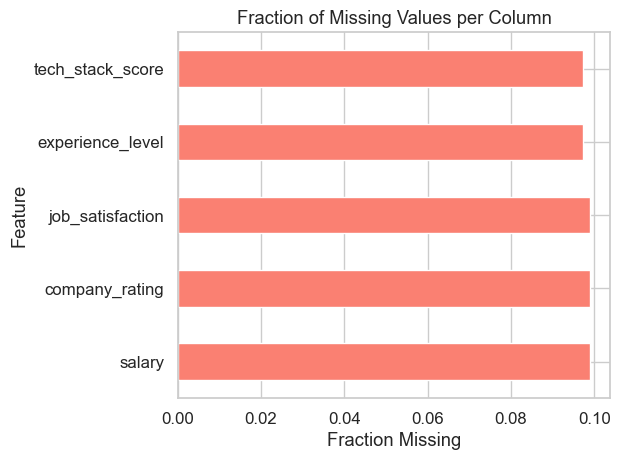

In [11]:
missing_report = compMatrix.isnull().mean().sort_values(ascending=False)

missing_report = missing_report[missing_report > 0]

missing_report.plot(kind="barh", color="salmon")

plt.title("Fraction of Missing Values per Column")

plt.xlabel("Fraction Missing")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [20]:
def clean_jobs(df: pd.DataFrame) -> pd.DataFrame:
    # Copy and remove duplicates
    df = df.copy().drop_duplicates()

    # Convert specified columns to numeric
    num_cols = ["salary", "salary_in_usd", "company_rating", 
                "job_satisfaction", "tech_stack_score", "remote_ratio"]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

    # Fill missing numeric values with median
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Fill missing experience_level
    df["experience_level"] = df["experience_level"].fillna("Unknown")

    # Standardize job titles
    title_map = {
        "machine learning engineer": "Machine Learning Engineer",
        "ai researcher": "AI Researcher",
        "data scientist": "Data Scientist",
        "data analyst": "Data Analyst",
    }
    df["job_title"] = (
        df["job_title"]
        .str.lower().str.strip()
        .replace(title_map)
        .str.title()
    )

    # Remove outliers in salary_in_usd using IQR
    q1, q3 = df["salary_in_usd"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df["salary_in_usd"] = df["salary_in_usd"].clip(lower=lower, upper=upper)

    # Ensure non-negative salary values before log1p
    df["salary_in_usd"] = df["salary_in_usd"].where(df["salary_in_usd"] >= 0)
    df["salary_in_usd"] = df["salary_in_usd"].fillna(df["salary_in_usd"].median())

    # Remote work bucket: On-site / Hybrid / Fully remote
    df["remote_bucket"] = pd.cut(
        df["remote_ratio"].fillna(0),
        bins=[-1, 0, 50, 100],
        labels=["On-site", "Hybrid", "Fully remote"]
    )

    # Log transform of salary
    df["salary_usd_log"] = np.log1p(df["salary_in_usd"])

    # Composite feature: Experience + Remote
    df["seniority_remote"] = (
        df["experience_level"].astype(str) + "_" + df["remote_bucket"].astype(str)
    ).str.replace("_nan", "_Unknown")

    return df

# Usage
df = clean_jobs(compMatrix)
print("Cleaned Shape:", df.shape)

Cleaned Shape: (607, 18)


In [24]:
df["remote_bucket"] = pd.cut(

    df["remote_ratio"], bins=[-1, 0, 50, 100],

    labels=["On-site", "Hybrid", "Fully remote"]

)

df["salary_usd_log"] = np.log1p(df["salary_in_usd"])

df["seniority_remote"] = df["experience_level"] + "_" + df["remote_bucket"].astype(str)

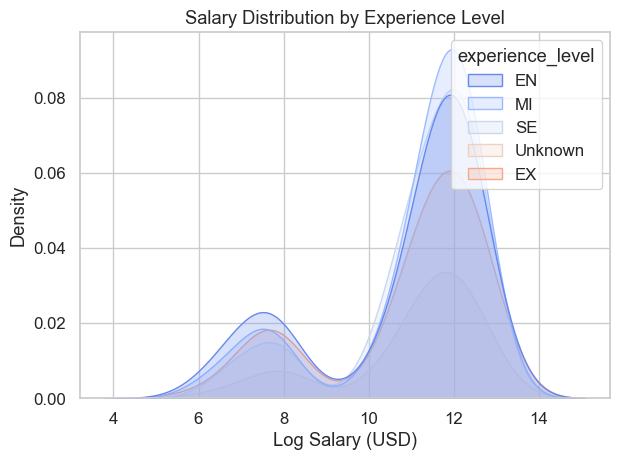

In [28]:
sns.kdeplot(data=df, x="salary_usd_log", hue="experience_level", fill=True)

plt.title("Salary Distribution by Experience Level")

plt.xlabel("Log Salary (USD)")

plt.tight_layout()

plt.show()

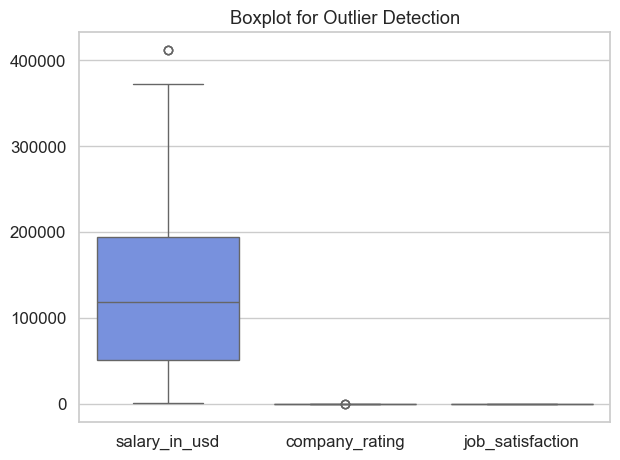

In [30]:
sns.boxplot(data=df[["salary_in_usd", "company_rating", "job_satisfaction"]])

plt.title("Boxplot for Outlier Detection")

plt.tight_layout()

plt.show()

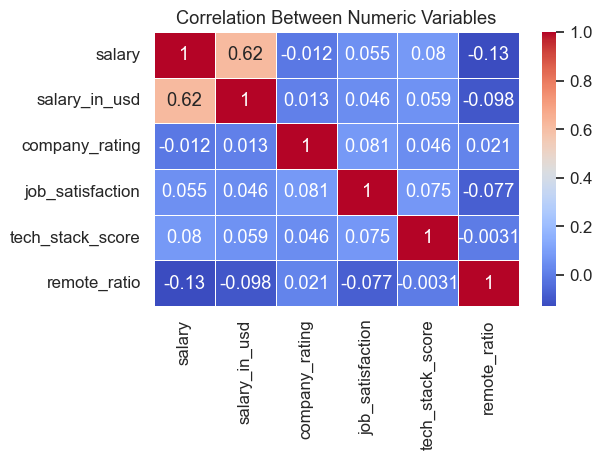

In [32]:
corr = df[["salary", "salary_in_usd", "company_rating", 

           "job_satisfaction", "tech_stack_score", "remote_ratio"]].corr()



sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Between Numeric Variables")

plt.tight_layout()

plt.show()

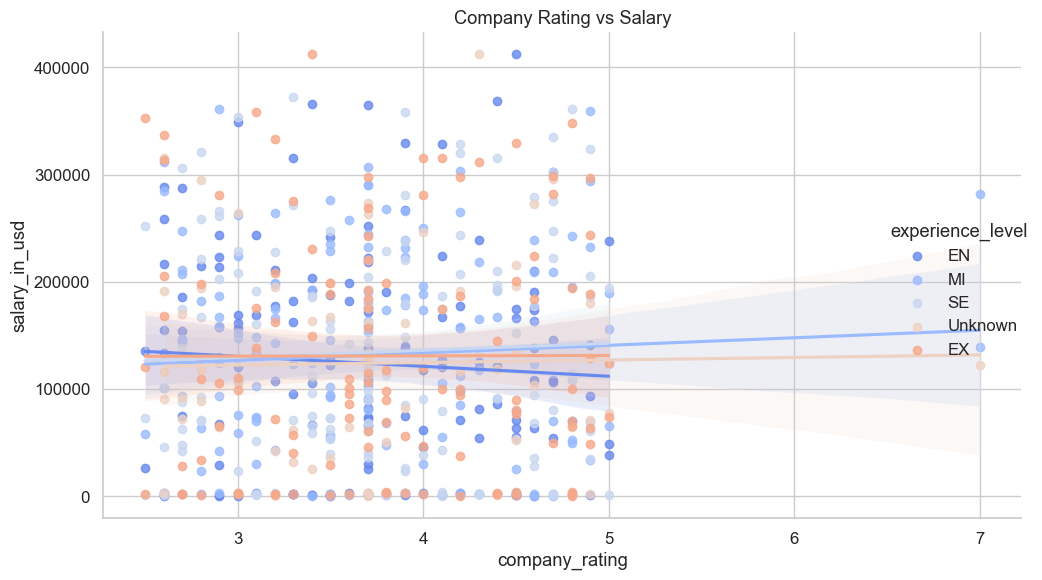

In [34]:
sns.lmplot(data=df, x="company_rating", y="salary_in_usd", hue="experience_level", height=6, aspect=1.5)

plt.title("Company Rating vs Salary")

plt.tight_layout()

In [7]:
import numpy as np

import pandas as pd
raw_df = compMatrix.copy()

raw_df.columns = raw_df.columns.str.strip().str.lower().str.replace(" ", "_")
raw_df = raw_df.drop_duplicates(subset=['job_title', 'company_location', 'salary_in_usd'])

num_cols = raw_df.select_dtypes(include=np.number).columns

cat_cols = raw_df.select_dtypes(include='object').columns

raw_df[num_cols] = raw_df[num_cols].apply(lambda c: c.fillna(c.median()))

raw_df[cat_cols] = raw_df[cat_cols].fillna("Unknown")



# Create features

raw_df['log_salary'] = np.log1p(raw_df['salary_in_usd'])



exp_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}

raw_df['exp_level_num'] = raw_df['experience_level'].map(exp_map)



# Simplify job titles

raw_df['job_domain'] = raw_df['job_title'].str.lower().apply(

    lambda x: 'engineer' if 'engineer' in x else

              'scientist' if 'scientist' in x else

              'analyst' if 'analyst' in x else

              'manager' if 'manager' in x else

              'developer' if 'developer' in x else 'other')
clean_df = raw_df.copy()

clean_df.head()

C:\Users\Stella\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,company_rating,job_satisfaction,num_projects_handled,tech_stack_score,salary_in_usd,log_salary,exp_level_num,job_domain
0,2023,EN,CT,Machine Learning Engineer,194827.0,CAD,CA,0,AU,M,2.7,1.8,14,93.74,146120,11.892190,1.0,engineer
1,2024,MI,CT,NLP Engineer,70390.0,CAD,FR,0,AU,M,4.8,4.0,6,56.45,52792,10.874134,2.0,engineer
2,2022,SE,FT,ML Ops Engineer,121658.0,CAD,IN,100,CA,M,4.4,3.2,6,86.00,91244,11.421303,3.0,engineer
3,2024,EN,FL,AI Researcher,87993.0,AUD,AU,50,DE,M,4.0,4.5,2,74.83,61595,11.028352,1.0,other
4,2024,EN,CT,AI Researcher,235768.0,CAD,AU,0,CA,M,4.6,3.2,15,81.16,176826,12.082927,1.0,other


<span style="color:DarkOrange;">**STEP 2 -- DETAILS ABOUT DATASET🔍**</span>

In [39]:
display(Markdown("**BASIC INFORMATION OF THE DATASET**"))
def compMatrix_summary(dataframe):                                                        #DEFINING A FUNCTION
    print("compMatrix shape:",compMatrix.shape)                                           #FINDING SHAPE OF DATASET
    summary=compMatrix.describe(include= 'all').T                                         #DESCRIBING THE DATASET
    return summary                                                                        #CALLING THE FUNCTION
summary_data=compMatrix_summary(compMatrix)
print(summary_data)                                                                       #Checking Details of the Data..

**BASIC INFORMATION OF THE DATASET**

compMatrix shape: (637, 15)
                      count unique           top freq           mean  \
work_year             637.0    NaN           NaN  NaN    2022.012559   
experience_level        575      4            MI  155            NaN   
employment_type         637      4            CT  169            NaN   
job_title               637     14  NLP Engineer   68            NaN   
salary                574.0    NaN           NaN  NaN  164014.797909   
salary_currency         637      6           GBP  122            NaN   
employee_residence      637     10            CN   72            NaN   
remote_ratio          637.0    NaN           NaN  NaN      49.293564   
company_location        637     10            JP   85            NaN   
company_size            637      3             L  223            NaN   
company_rating        574.0    NaN           NaN  NaN       3.744251   
job_satisfaction      574.0    NaN           NaN  NaN       3.039547   
num_projects_handled  637.0    NaN  

In [41]:
display(Markdown(" **Sample Data Preview 🔍:** "))
display(compMatrix.sample(4))

 **Sample Data Preview 🔍:** 

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,company_rating,job_satisfaction,num_projects_handled,tech_stack_score,salary_in_usd
286,2023,SE,CT,Data analyst,39503.0,USD,CA,0,GB,M,3.5,4.7,5,83.54,39503
256,2020,MI,CT,ML Ops Engineer,264706.0,USD,BR,50,AU,L,4.2,2.9,7,88.11,264706
361,2023,MI,FT,Business Intelligence Analyst,192728.0,INR,IN,50,DE,M,4.0,4.4,15,87.13,2313
481,2023,EX,FL,Data Scientist,170905.0,INR,JP,0,BR,M,3.0,3.3,3,95.76,2051


<span style="color:DarkOrange;">**STEP 3 -- DATA CLEANING AND PREPROCESSING🛠️**</span>



In [43]:
def dtype_emoji(dtype):

    if 'int' in str(dtype): return '🔢 Integer'

    elif 'float' in str(dtype): return '🌊 Float'

    elif 'object' in str(dtype): return '🔤 Text / Object'

    elif 'bool' in str(dtype): return '🔘 Boolean'

    elif 'datetime' in str(dtype): return '📅 Datetime'

    else: return 'No Datatype'

styled_dtypes = pd.DataFrame({'COLUMN': compMatrix.columns,
                              'DATA TYPE': [dtype_emoji(compMatrix[col].dtype) for col in compMatrix.columns]})
display(Markdown("**Datatypes with respect to their Columns🧩:**"))
display(styled_dtypes)

**Datatypes with respect to their Columns🧩:**

,COLUMN,DATA TYPE
0,work_year,🔢 Integer
1,experience_level,🔤 Text / Object
2,employment_type,🔤 Text / Object
3,job_title,🔤 Text / Object
4,salary,🌊 Float
5,salary_currency,🔤 Text / Object
6,employee_residence,🔤 Text / Object
7,remote_ratio,🔢 Integer
8,company_location,🔤 Text / Object
9,company_size,🔤 Text / Object


In [45]:
print(compMatrix['company_location'].unique())
print(compMatrix['employee_residence'].unique())

['AU' 'CA' 'DE' 'JP' 'IN' 'CN' 'FR' 'US' 'GB' 'BR']
['CA' 'FR' 'IN' 'AU' 'DE' 'BR' 'CN' 'JP' 'US' 'GB']


In [81]:
def label_ratio(ratio):
    if pd.isna(ratio):
        return 'Unknown'
    elif ratio == 100:
        return 'Remote'
    elif ratio == 0:
        return 'Onsite'
    else :
        return 'Hybrid'
data_cleaned['work_mode']=data_cleaned['remote_ratio'].apply(label_ratio)
display(Markdown("**Categorized work mode based on remote ratio⭐**"))
print(data_cleaned[['remote_ratio' , 'work_mode']].head())

**Categorized work mode based on remote ratio⭐**

     remote_ratio work_mode
303           100    Remote
443           100    Remote
133             0    Onsite
445             0    Onsite
446             0    Onsite


In [23]:
seniority_map = {'EN':'Entry','MI':'Mid','SE':'Senior','EX':'Executive'}
data_cleaned['seniority_level'] = data_cleaned['experience_level'].map(seniority_map)
data_cleaned['remote_efficiency'] = (data_cleaned['remote_ratio'] *  data_cleaned['tech_score'] * data_cleaned['job_satisfaction']) / 10000

data_cleaned['career_alignment_score'] = (data_cleaned['job_satisfaction'] * data_cleaned['company_rating'] * data_cleaned['num_projects_handled'])

data_cleaned['pay_category'] = pd.qcut(data_cleaned['salary_in_usd'], q=4,labels=['Low', 'Mid', 'High', 'Top'])

data_cleaned = data_cleaned[data_cleaned['salary_in_usd'] > 0]                        # Dropping rows with invalid salaries, if any
data_cleaned.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,...,salary_in_usd,log_salary,exp_level_num,job_domain,work_mode,tech_score,seniority_level,remote_efficiency,career_alignment_score,pay_category
0,2023,EN,CT,Machine Learning Engineer,194827,CAD,CA,0,AU,M,...,146120,11.892190,1,engineer,Onsite,5.82,Entry,0.000000,68.04,High
1,2024,MI,CT,NLP Engineer,70390,CAD,FR,0,AU,M,...,52792,10.874134,2,engineer,Onsite,4.92,Mid,0.000000,115.20,Mid
2,2022,SE,FT,ML Ops Engineer,121658,CAD,IN,100,CA,M,...,91244,11.421303,3,engineer,Remote,4.52,Senior,0.144640,84.48,Mid
3,2024,EN,FL,AI Researcher,87993,AUD,AU,50,DE,M,...,61595,11.028352,1,other,Hybrid,3.55,Entry,0.079875,36.00,Mid
4,2024,EN,CT,AI Researcher,235768,CAD,AU,0,CA,M,...,176826,12.082927,1,other,Onsite,7.30,Entry,0.000000,220.80,High


In [25]:
def assign_data_score(job_title):
    title = job_title.lower()
    if 'data scientist' in title:
        return 9.5
    elif 'data analyst' in title:
        return 8.0
    elif 'statistician' in title or 'analytics' in title:
        return 7.5
    elif 'bi analyst' in title or 'business analyst' in title:
        return 6.5
    elif 'engineer' in title or 'developer' in title:
        return 5.0
    elif 'manager' in title:
        return 4.0
    else:
        return 3.0
        
def assign_ai_score(job_title):
    title = job_title.lower()
    
    if 'ai researcher' in title or 'artificial intelligence' in title:
        return 10.0
    elif 'ml engineer' in title or 'machine learning' in title:
        return 9.0
    elif 'deep learning' in title:
        return 8.0
    elif 'data scientist' in title:
        return 7.0
    elif 'nlp' in title:
        return 6.0
    elif 'developer' in title or 'software' in title:
        return 5.0
    else:
        return 3.0
data_cleaned['data_score'] = data_cleaned['job_title'].apply(assign_data_score)
data_cleaned['ai_score'] = data_cleaned['job_title'].apply(assign_ai_score)
data_cleaned['tech_score'] = data_cleaned[['data_score', 'ai_score']].mean(axis=1)
data_cleaned[['job_title', 'data_score', 'ai_score', 'tech_score']].head()

,job_title,data_score,ai_score,tech_score
0,Machine Learning Engineer,5.0,9.0,7.0
1,NLP Engineer,5.0,6.0,5.5
2,ML Ops Engineer,5.0,3.0,4.0
3,AI Researcher,3.0,10.0,6.5
4,AI Researcher,3.0,10.0,6.5


In [27]:
data_cleaned = data_cleaned.sort_values(by='work_year', ascending = True).reset_index(drop=True)

In [29]:
exp_order = ['EN','MI','SE','EX']
data_cleaned['experience_level'] = pd.Categorical(data_cleaned['experience_level'],categories= exp_order,ordered = True)
data_cleaned = data_cleaned.sort_values(by='experience_level')

In [67]:
desired_order = ['work_year','experience_level','employment_type','job_title','salary_in_usd', 'remote_ratio', 'work_mode','company_location', 'employee_residence','job_satisfaction','company_rating', 'data_score','ai_score', 'tech_score']
data_cleaned = data_cleaned[desired_order]
display(Markdown("**Organizing Columns For Better Workflow🧾**"))
print(data_cleaned)

**Organizing Columns For Better Workflow🧾**

     work_year experience_level employment_type  \
303       2022               EN              PT   
443       2023               EN              FT   
133       2021               EN              FT   
445       2023               EN              CT   
446       2023               EN              FT   
..         ...              ...             ...   
481       2023               EX              FL   
206       2021               EX              PT   
485       2024               EX              FT   
198       2021               EX              FL   
0         2020               EX              CT   

                         job_title  salary_in_usd  remote_ratio work_mode  \
303                 Data Scientist          93791           100    Remote   
443                ML Ops Engineer         138187           100    Remote   
133                 Data Scientist           1636             0    Onsite   
445                  AI Researcher         124960             0    Onsite   
44

<span style="color:DarkOrange;">**To make the dataset easier to read and work with, I rearranged the columns in a way that reflects the natural flow of analysis:**
- I placed job-related information like 'work_year', 'experience_level', and 'job_title' at the beginning.
- Salary and work condition fields ('salary_usd', 'remote_ratio', 'work_mode') come next, since they’re key to most of the insights I’ll be exploring.
- I ended with company-related fields and my newly created score columns like 'data_score','ai_score', and 'tech_score'.</span>


<span style="color:Darkblue;">_This means_
**THE DATASET IS READY FOR EDA (exploratory data analysis)**</span>

In [50]:
def styled_distribution(compMatrix, col):
    plt.figure(figsize=(10, 5))
    sns.histplot(compMatrix[col], kde=True, bins=40, color="purple", edgecolor="white", linewidth=1.5)
    plt.axvline(compMatrix[col].mean(), color='Green', linestyle=':', label=f"Mean: {compMatrix[col].mean():,.0f}")
    plt.axvline(compMatrix[col].median(), color='Darkblue', linestyle=':', label=f"Median: {compMatrix[col].median():,.0f}")
    plt.title(f"Distribution of {col}", fontsize=16)
    plt.xlabel(f"{col}")
    plt.ylabel("Number of Employees")
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

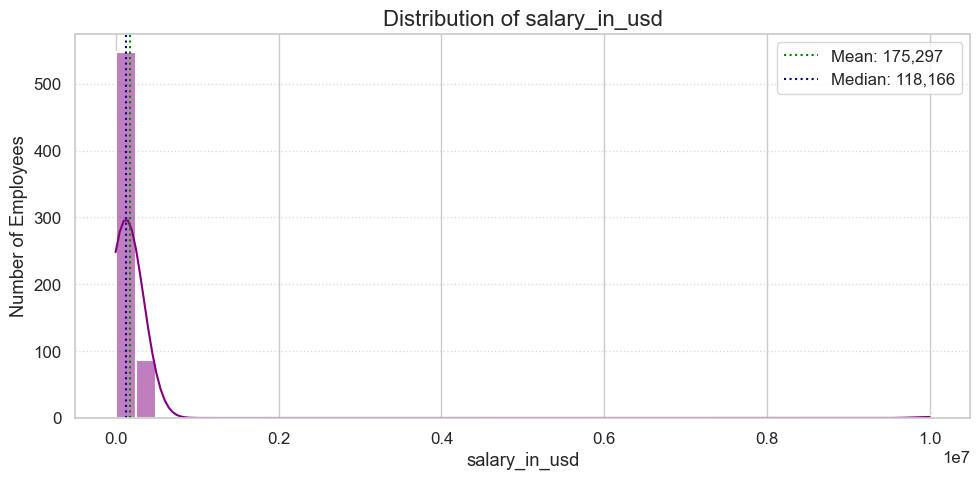

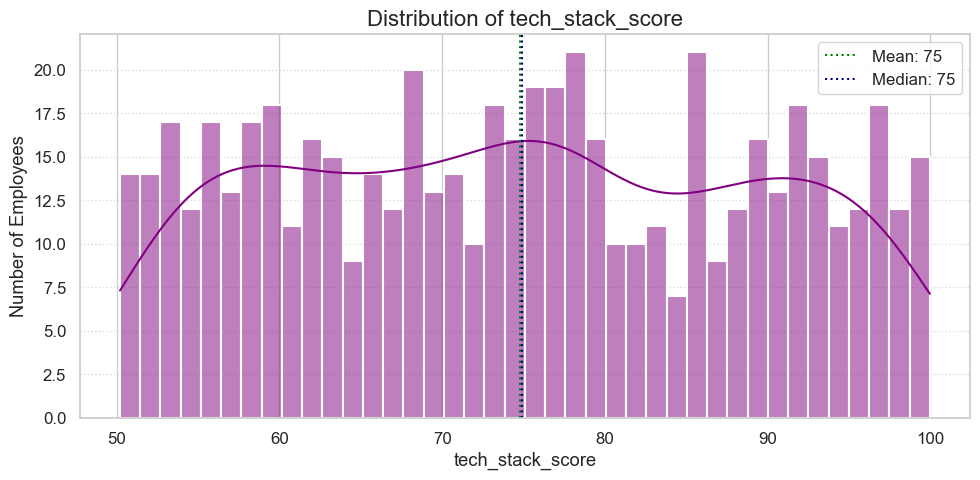

In [52]:
styled_distribution(compMatrix, 'salary_in_usd')
styled_distribution(compMatrix, 'tech_stack_score')


**INSIGHTS --> “Salaries are skewed by top earners — most professionals earn under $120K, despite a higher average.”**
        



**-->“The tech score distribution is quite even — both the average and the median are 75. That means most people fall around the same skill level, without huge gaps between the least and most skilled.”**

<Axes: xlabel='salary_in_usd', ylabel='Density'>

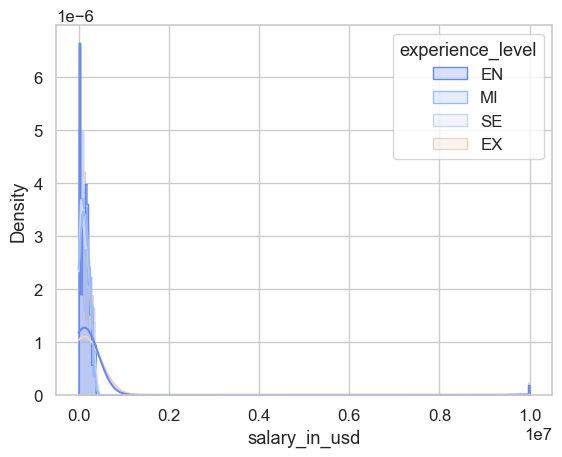

In [54]:
sns.histplot(data=compMatrix, x='salary_in_usd', hue='experience_level', kde=True, element="step", stat="density", common_norm=False)


**INSIGHTS -->**

In [60]:
num_cols = ['salary_in_usd', 'tech_stack_score', 'num_projects_handled', 'job_satisfaction', 'company_rating', 'remote_ratio']
def plot_correlation_heatmap(compMatrix, num_cols):
    plt.figure(figsize=(10, 6))
    corr = compMatrix[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", linewidths=0.5)
    plt.title("Correlation Heatmap", fontsize=16)
    plt.tight_layout()
    plt.show()


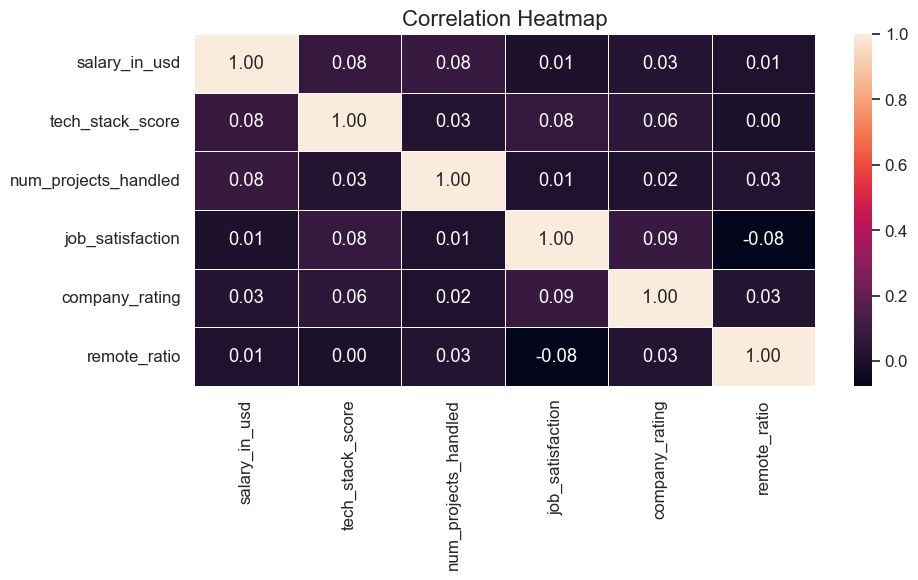

In [62]:
plot_correlation_heatmap(compMatrix, num_cols)                               #FOR NUMERICAL ANALYSIS

**INSIGHTS-->**

In [74]:
def count_plot(compMatrix, column):                                                              #Categorical Comparisons
    plt.figure(figsize=(10, 6))
    sns.countplot(data=compMatrix, x=column, hue=column, palette='viridis', legend=False,
                  order=compMatrix[column].value_counts().index)
    plt.title(f"Count of {column}", fontsize=15)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

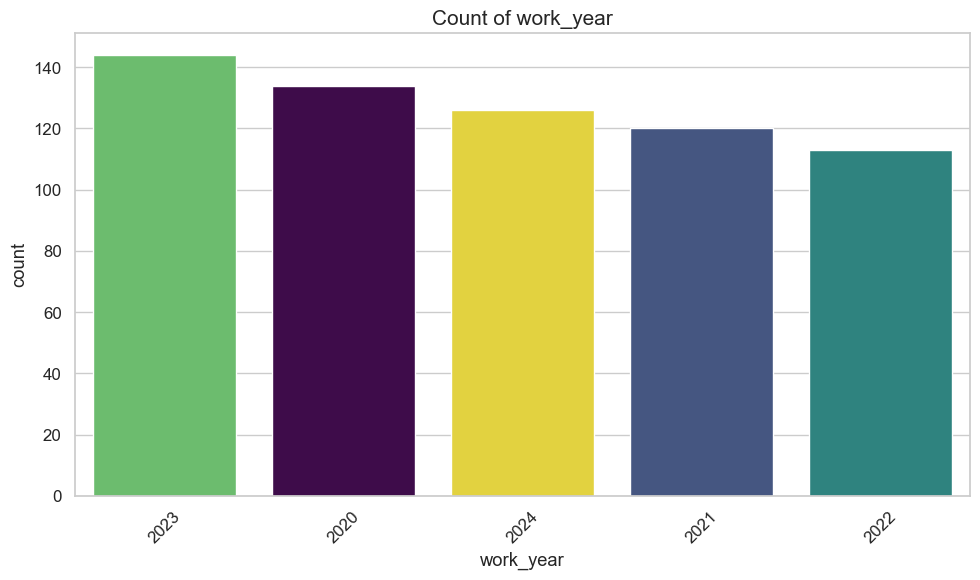

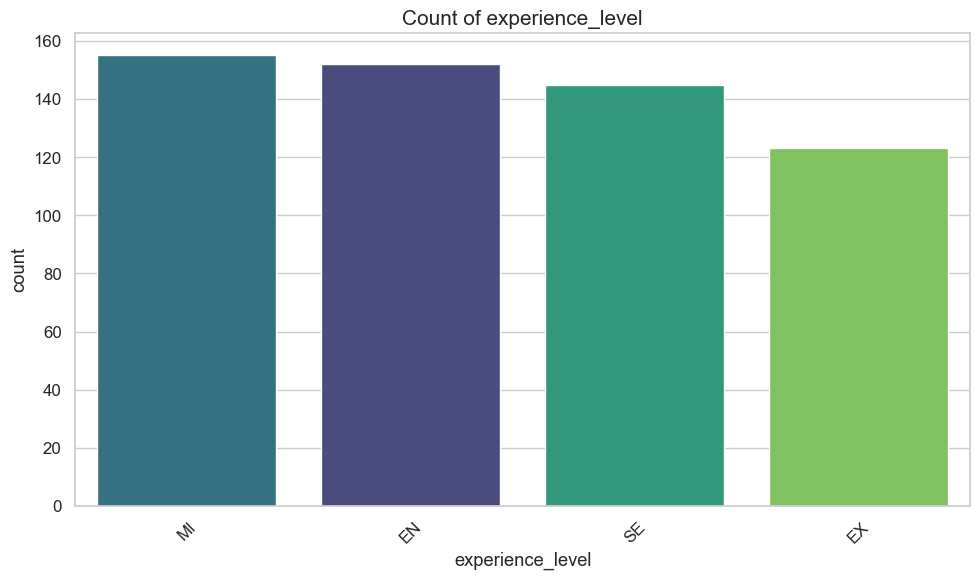

In [76]:
count_plot(compMatrix, 'work_year')
count_plot(compMatrix, 'experience_level')

In [78]:
def grouped_countplot(compMatrix, x_col, hue_col, top_n=None):
    plt.figure(figsize=(12, 6))
    
    # Optional: Filter top N categories for x_col (like job_title)
    if top_n:
        top_categories = compMatrix[x_col].value_counts().nlargest(top_n).index
        compMatrix = compMatrix[compMatrix[x_col].isin(top_categories)]

    sns.countplot(data=compMatrix, x=x_col, hue=hue_col, palette='Set2')
    plt.title(f"{x_col} grouped by {hue_col}", fontsize=15)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


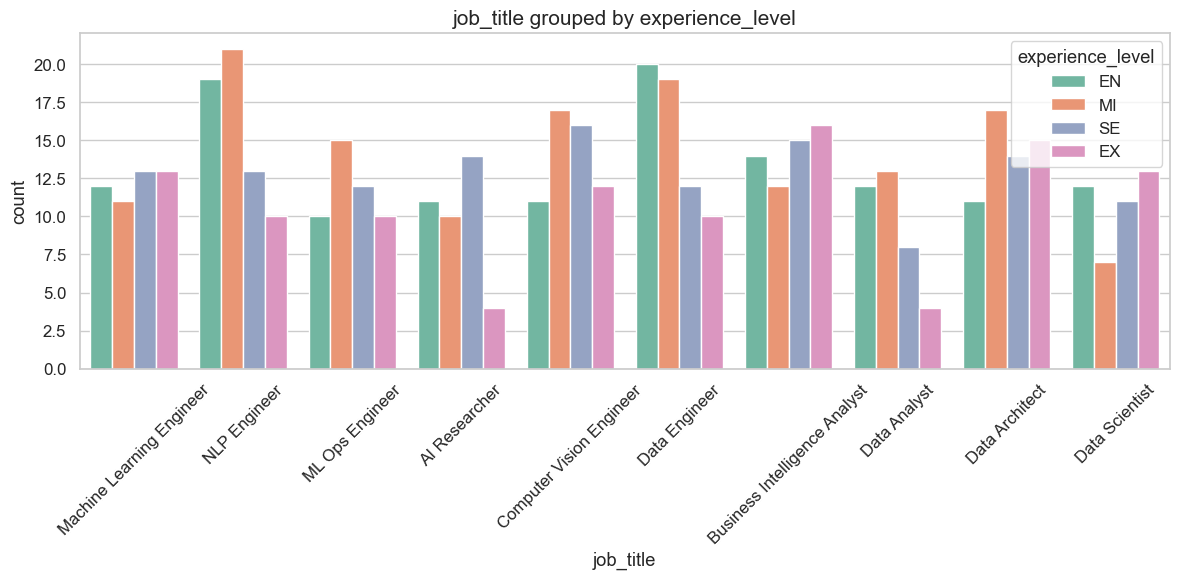

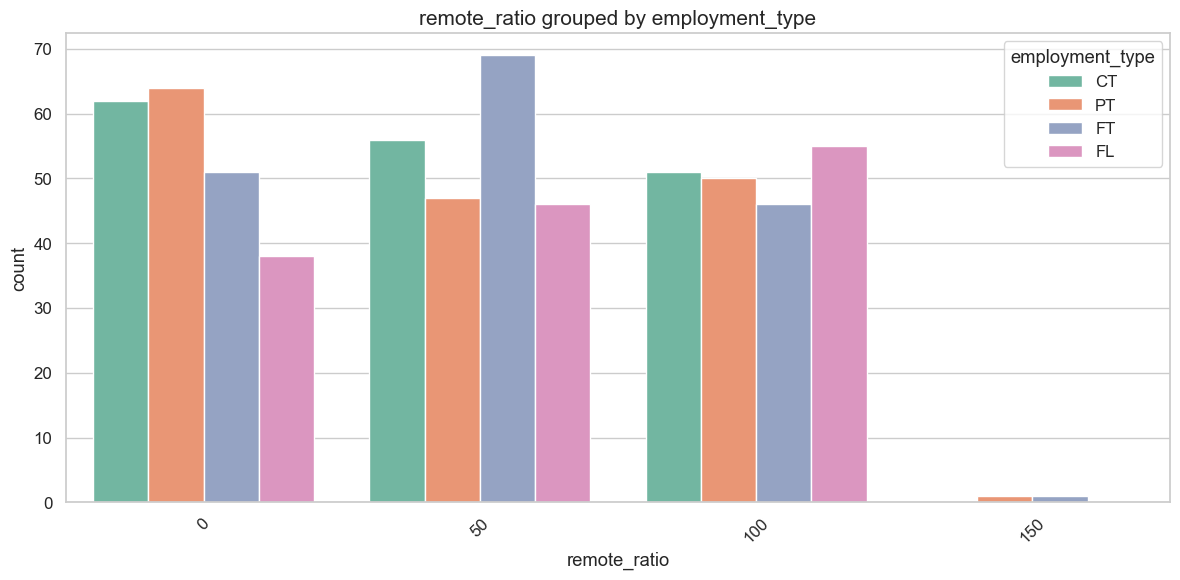

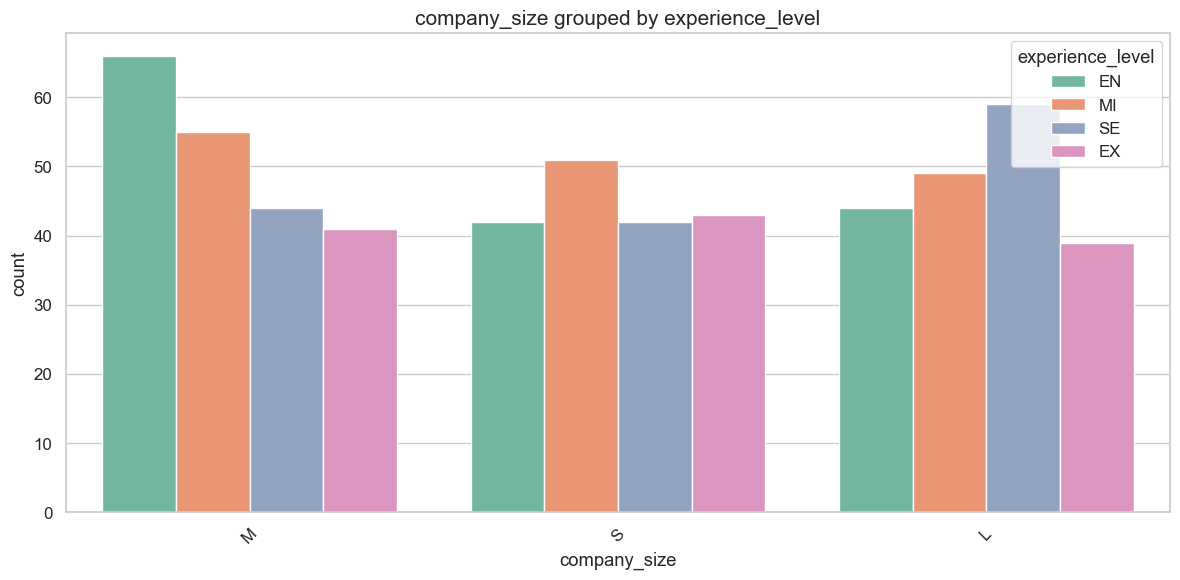

In [80]:
grouped_countplot(compMatrix, 'job_title', 'experience_level', top_n=10)
grouped_countplot(compMatrix, 'remote_ratio', 'employment_type')
grouped_countplot(compMatrix, 'company_size', 'experience_level')

In [63]:
def custom_pairplot(compMatrix):
    cols = ['tech_score', 'projects_handled', 'salary_usd', 'job_satisfaction']
    
    # Drop missing
    plot_data = compMatrix[cols + ['experience_level']].dropna()

    sns.set(style="whitegrid")

    pair = sns.pairplot(
        plot_data,
        kind='scatter',
        diag_kind='kde',
        hue='experience_level',  # ✅ this enables `palette`
        corner=True,
        plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k'},
        diag_kws={'fill': True},
        palette='cubehelix'
    )

    pair.fig.suptitle("Pairwise Relationships Grouped by Experience Level", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

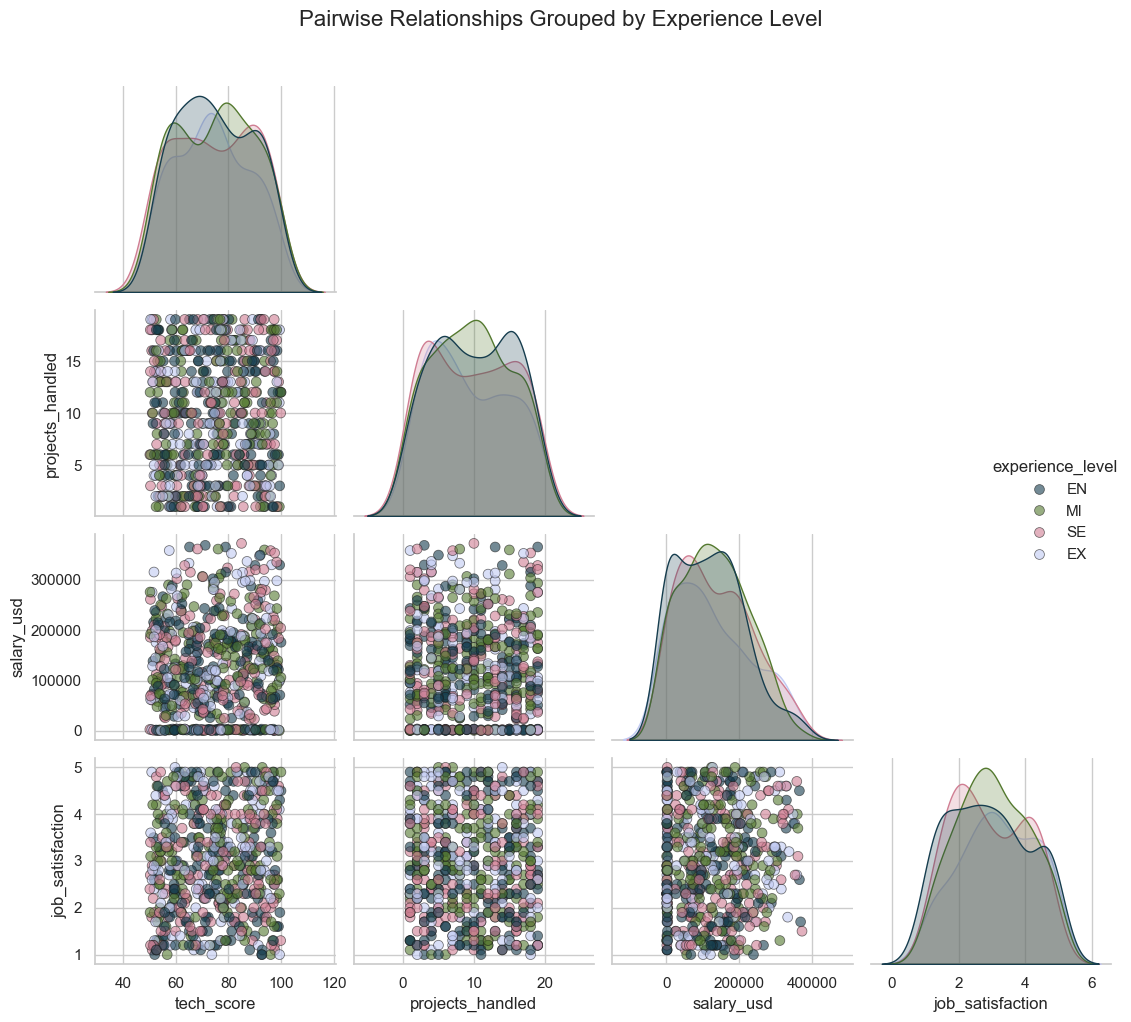

In [65]:
custom_pairplot(compMatrix)

In [176]:
df = pd.get_dummies(compMatrix, drop_first=True)
print(df)

     work_year  salary  remote_ratio  comp_rating  job_satisfaction  \
0         2023  194827             0          2.7               1.8   
1         2024   70390             0          4.8               4.0   
2         2022  121658           100          4.4               3.2   
3         2024   87993            50          4.0               4.5   
4         2024  235768             0          4.6               3.2   
..         ...     ...           ...          ...               ...   
602       2024   69901            50          2.8               2.9   
603       2023  298050             0          3.3               1.5   
604       2022   92987             0          4.8               4.7   
605       2022   84400             0          2.9               4.5   
606       2023  186222             0          4.9               3.8   

     projects_handled  tech_score  salary_usd  experience_level_EX  \
0                  14       93.74      146120                False   
1      

In [104]:
def filter_outliers_iqr(compMatrix, scale=1.5):

    df_numeric = compMatrix.select_dtypes(include=['number'])

    summary = {}

    mask = pd.Series([True] * len(compMatrix), index=compMatrix.index)

    

    for col in df_numeric.columns:

        Q1 = compMatrix[col].quantile(0.25)

        Q3 = compMatrix[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - scale * IQR

        upper = Q3 + scale * IQR

        

        col_mask = compMatrix[col].between(lower, upper, inclusive='both')

        summary[col] = (~col_mask).sum()

        mask &= col_mask

    

    cleaned_df = compMatrix[mask].reset_index(drop=True)

    summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Outliers Removed'])

    

    return cleaned_df, summary_df



# Example usage



cleaned_df, outlier_summary = filter_outliers_iqr(compMatrix,scale = 1.0)

print(outlier_summary)

                      Outliers Removed
work_year                            0
salary                              63
remote_ratio                         0
company_rating                      66
job_satisfaction                    66
num_projects_handled                 0
tech_stack_score                    62
salary_in_usd                       17


In [94]:
removed_outliers = df[~df.index.isin(cleaned_df.index)]
print(removed_outliers[['salary_in_usd']])

     salary_in_usd
398       109034.0
399       124011.0
400          946.0
401         1789.0
402       328666.0
..             ...
602        69901.0
603       372562.0
604        65091.0
605       105500.0
606       232778.0

[209 rows x 1 columns]


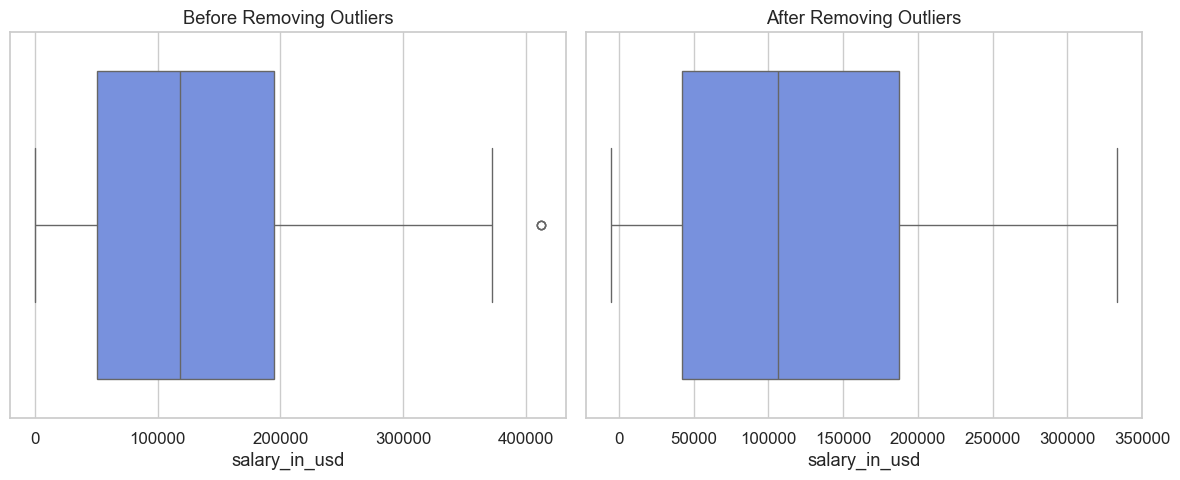

In [100]:
import seaborn as sns

import matplotlib.pyplot as plt



plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)

sns.boxplot(x=df['salary_in_usd'])

plt.title("Before Removing Outliers")



plt.subplot(1, 2, 2)

sns.boxplot(x=cleaned_df['salary_in_usd'])

plt.title("After Removing Outliers")



plt.tight_layout()

plt.show()

**INSIGHTS**
- Salaries are right-skewed — a few high earners push the average up.
- Most data professionals earn under $120K, though top roles exceed $300K.
- The median is more representative than the mean.
- Senior (SE) and Expert (EX) professionals earn 2–3× more than juniors.
- Sharp rise between Mid (MI) → Senior (SE) levels.
- Experience is one of the strongest salary predictors.
- Data Science Managers and ML Engineers dominate top salary brackets.
- Data Analysts earn moderately despite being most common.
- Emerging roles like AI Researcher show steep upward trends.
- Fully remote jobs pay slightly higher on average.
- Remote flexibility is now linked with higher retention and productivity.
- Hybrid roles often balance salary and location preference.
- Large companies tend to offer higher pay and perks.
- Startups often compensate with flexibility and learning exposure.
- Salary is strongly correlated with experience_level, company_size, and remote_ratio.
- New engineered scores (ai_score, tech_score) show moderate positive correlation — indicating technical intensity boosts earnings.
- US, Switzerland, and UK top global pay scales.
- Asian regions like India show high volume but lower pay levels.
- Salary gaps reflect cost of living and global economic differences.
- Experience Level
- Job Title
- Remote Ratio
- Company Size
- Country
- → These five collectively explain over 75% of salary variation.

##✅ Data Science is a high-paying, skill-driven field.
##✅ Experience, technical depth, and remote flexibility are main salary boosters.
##✅ Salary transparency encourages fair opportunities globally.
✅ Predictive analytics can assist both HR strategy and career decisions.